In [1]:
!pip uninstall -y torch torchvision torchaudio


!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu118
!pip install transformers==4.41.0

!wget https://github.com/state-spaces/mamba/releases/download/v2.2.2/mamba_ssm-2.2.2+cu122torch2.3cxx11abiFALSE-cp311-cp311-linux_x86_64.whl

!pip install mamba_ssm-2.2.2+cu122torch2.3cxx11abiFALSE-cp311-cp311-linux_x86_64.whl

!pip install causal-conv1d>=1.4.0

import torch
print("PyTorch:", torch.__version__)  # e.g., 2.1.0+cu121
print("CUDA:", torch.version.cuda)    # e.g., 12.1
!python --version   

import torch
import random
import torch.nn as nn
import torch.nn.functional as F
from mamba_ssm import Mamba
from torch.optim import Adam
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
from tqdm import tqdm
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer
from transformers import GPT2Tokenizer
from mamba_ssm.models.mixer_seq_simple import MixerModel
from mamba_ssm.models.mixer_seq_simple import MambaLMHeadModel
from transformers import AutoModelForCausalLM
from mamba_ssm.models.config_mamba import MambaConfig

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.7/839.7 MB 1.9 MB/s eta 0:00:000:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 5.4 MB/s eta 0:00:000:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 73.3 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 78.9 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 28.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 94.1 MB/s eta 0:00:00:00:0100:

In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader

def prepare_stock_data(file_path, seq_length=30, pred_length=5, test_size=0.1, val_size=0.1):
    df = pd.read_csv(file_path)
    
    print("✅ Original Data:")
    print(f"📐 Shape: {df.shape}")
    print(f"🧾 Columns: {df.columns.tolist()}")
    print("\n🔍 Sample Data:")
    print(df.head())

    # Clean numeric columns
    numeric_cols = ['Price', 'Open', 'High', 'Low', 'Change %']
    for col in numeric_cols:
        df[col] = df[col].str.replace(',', '').str.replace('%', '').astype(float)
    
    # Handle volume separately (contains '-' for missing values)
    df['Vol.'] = df['Vol.'].replace('-', '0').str.replace(',', '').astype(float)
    
    # Convert and sort by date
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    # Feature engineering
    df['Daily_Spread'] = df['High'] - df['Low']
    df['Log_Vol'] = np.log1p(df['Vol.'])  # Log transform volume
    
    # Selected features
    features = ['Price', 'Open', 'High', 'Low', 'Daily_Spread', 'Change %', 'Log_Vol']
    
    # Normalize features
    scaler = StandardScaler()
    df[features] = scaler.fit_transform(df[features])
    
    # Create sequences and targets
    def create_sequences(data, seq_len, pred_len):
        X, y = [], []
        for i in range(len(data) - seq_len - pred_len + 1):
            X.append(data[i:i+seq_len])
            y.append(data[i+seq_len:i+seq_len+pred_len, 0])  # Predict 'Price'
        return np.array(X), np.array(y)
    
    sequences, targets = create_sequences(df[features].values, seq_length, pred_length)

    total_samples = len(sequences)

    # Split off test set
    test_split_idx = int(total_samples * (1 - test_size))
    X_temp, y_temp = sequences[:test_split_idx], targets[:test_split_idx]
    X_test, y_test = sequences[test_split_idx:], targets[test_split_idx:]

    # Split remaining into train and validation sets
    val_split_idx = int(len(X_temp) * (1 - val_size))
    X_train, y_train = X_temp[:val_split_idx], y_temp[:val_split_idx]
    X_val, y_val = X_temp[val_split_idx:], y_temp[val_split_idx:]

    # Convert to PyTorch tensors
    train_data = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
    val_data = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))
    test_data = TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test))

    print("\n✅ Processed Data:")
    print(f"🧠 Training sequences: {X_train.shape} (samples, seq_len, features)")
    print(f"🎯 Training targets: {y_train.shape} (samples, pred_len)")
    print(f"🔍 Validation sequences: {X_val.shape}")
    print(f"🔎 Validation targets: {y_val.shape}")
    print(f"🏁 Test sequences: {X_test.shape}")
    print(f"🎯 Test targets: {y_test.shape}")
    
    return train_data, val_data, test_data, scaler, features


# Parameters
SEQ_LENGTH = 30
PRED_LENGTH = 5
TEST_SIZE = 0.1   # 10% test data
VAL_SIZE = 0.1    # 10% validation from remaining after test split
BATCH_SIZE = 32

# Prepare data
train_data, val_data, test_data, scaler, features = prepare_stock_data(
    file_path='/kaggle/input/stock-dhaka/Dhaka Stock Exchange Broad Historical Data.csv',
    seq_length=SEQ_LENGTH,
    pred_length=PRED_LENGTH,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE
)

# Create dataloaders
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)


✅ Original Data:
📐 Shape: (1805, 7)
🧾 Columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

🔍 Sample Data:
           Date     Price      Open      High       Low Vol. Change %
0  Sep 21, 2020  5,100.73  5,088.87  5,100.73  5,088.87    -    0.23%
1  Sep 20, 2020  5,088.87  5,104.65  5,131.05  5,083.33    -   -0.31%
2  Sep 17, 2020  5,104.65  5,116.81  5,134.89  5,098.06    -   -0.24%
3  Sep 16, 2020  5,116.81  5,100.54  5,128.40  5,100.54    -    0.32%
4  Sep 15, 2020  5,100.54  5,092.14  5,101.66  5,074.35    -    0.16%

✅ Processed Data:
🧠 Training sequences: (1433, 30, 7) (samples, seq_len, features)
🎯 Training targets: (1433, 5) (samples, pred_len)
🔍 Validation sequences: (160, 30, 7)
🔎 Validation targets: (160, 5)
🏁 Test sequences: (178, 30, 7)
🎯 Test targets: (178, 5)


In [34]:
import torch
import torch.nn as nn

class Add_Norm(nn.Module):
    def __init__(self, d_model, dropout, residual=True):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)
        self.residual = residual
    
    def forward(self, new, old):
        if self.residual:
            return self.norm(old + self.dropout(new))
        return self.norm(self.dropout(new))

class BimambaEncoderLayer(nn.Module):
    def __init__(self, d_model, d_conv, d_state, expand, 
                 b_d_conv, b_d_state, b_expand, dropout, d_ff, 
                 activation="relu", residual=True):
        super().__init__()
        # Mamba blocks (assumed defined elsewhere)
        self.mamba_forward = Mamba(
            d_model=d_model, d_state=d_state, d_conv=d_conv, expand=expand
        )
        self.mamba_backward = Mamba(
            d_model=d_model, d_state=b_d_state, d_conv=b_d_conv, expand=b_expand
        )
        # Normalization (pre-norm)
        self.norm = nn.LayerNorm(d_model)
        # Add/Norm layers
        self.addnorm1 = Add_Norm(d_model, dropout, residual=False)
        self.addnorm2 = Add_Norm(d_model, dropout, residual=False)
        self.addnorm3 = Add_Norm(d_model, dropout, residual=residual)
        # FFN
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.addnorm4 = Add_Norm(d_model, dropout, residual=residual)

    def forward(self, x, mask=None):
        x_norm = self.norm(x)
        
        # Forward Mamba block
        out_fwd = self.mamba_forward(x_norm)
        out_fwd = self.addnorm1(out_fwd, x)  # residual=False
        
        # Backward Mamba block
        rev_input = x_norm.flip(dims=[1])
        # rev_mask = mask.flip(dims=[1]) if mask is not None else None  # Not used because Mamba lacks mask support
        
        out_bwd = self.mamba_backward(rev_input)  # no mask passed
        out_bwd = out_bwd.flip(dims=[1])
        out_bwd = self.addnorm2(out_bwd, x)  # residual=False
        
        # Combine forward and backward outputs
        out = out_fwd + out_bwd
        out = self.addnorm3(out, x)  # residual=True
        
        # Feed Forward Network
        ffn_out = self.ffn(out)
        return self.addnorm4(ffn_out, out)  # residual=True

class StockMambaEncoder(nn.Module):
    def __init__(self, input_features=7, d_model=256, n_layer=6, 
                 d_conv=4, d_state=32, expand=2, 
                 b_d_conv=4, b_d_state=16, b_expand=2,
                 dropout=0.1, d_ff=512):
        super().__init__()
        # Input projection
        self.input_proj = nn.Linear(input_features, d_model)
        # Encoder layers
        self.layers = nn.ModuleList([
            BimambaEncoderLayer(
                d_model=d_model, d_conv=d_conv, d_state=d_state, expand=expand,
                b_d_conv=b_d_conv, b_d_state=b_d_state, b_expand=b_expand,
                dropout=dropout, d_ff=d_ff
            ) for _ in range(n_layer)
        ])
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x, mask=None):
        x = self.input_proj(x)
        for layer in self.layers:
            x = layer(x)  # mask is accepted but not used for now
        return x


In [35]:
import math
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module):
    """Positional encoding expects input shape (seq_len, batch, d_model)"""
    def __init__(self, d_model, dropout, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (seq_len, batch, d_model)
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)


class StockMambaDecoderLayer(nn.Module):
    def __init__(
        self,
        d_model,
        d_conv,
        d_state,
        expand,
        n_heads, 
        dropout,
        d_ff,
        activation="relu"  # Added activation parameter
    ):
        super().__init__()
        
        # Causal Mamba layer with residual connection
        self.causal_mamba = Mamba(
            d_model=d_model,
            d_state=d_state,
            d_conv=d_conv,
            expand=expand,
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        
        # Enhanced cross-attention
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout)
        
        # Improved FFN
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, target, encoder_output, src_mask=None):
        # 1. Causal Mamba block
        residual = target
        target = self.norm1(target)
        target = residual + self.dropout1(self.causal_mamba(target))
        
        # 2. Cross-attention block
        residual = target
        target = self.norm2(target)
        attn_out, attn_weights = self.cross_attn(
            query=target,
            key=encoder_output,
            value=encoder_output,
            key_padding_mask=src_mask  # True = ignore/mask
        )
        target = residual + self.dropout2(attn_out)
        
        # 3. FFN block
        residual = target
        target = self.norm3(target)
        target = residual + self.dropout3(self.ffn(target))
        
        return target, attn_weights


class StockMambaDecoder(nn.Module):
    def __init__(self,
                 d_model=64,
                 d_conv=4,
                 d_state=16,
                 expand=2,
                 n_heads=4,
                 n_layer=4,
                 dropout=0.1,
                 d_ff=256,
                 input_dim=7,  # Matches encoder's features
                 output_dim=1,
                 pred_length=5):  # Added prediction length
        super().__init__()
        self.pred_length = pred_length
        
        # Enhanced input projection
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model))
        
        # Positional encoding for temporal information
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        
        # Decoder layers
        self.layers = nn.ModuleList([
            StockMambaDecoderLayer(
                d_model=d_model,
                d_conv=d_conv,
                d_state=d_state,
                expand=expand,
                n_heads=n_heads,
                dropout=dropout,
                d_ff=d_ff,
                activation="relu"
            ) for _ in range(n_layer)
        ])
        
        # Multi-step output projection
        self.output_proj = nn.Sequential(
            nn.Linear(d_model, d_model*2),
            nn.GELU(),
            nn.Linear(d_model*2, output_dim * pred_length),  # Predict all steps at once
            nn.Unflatten(-1, (pred_length, output_dim))
        )
        
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p, gain=nn.init.calculate_gain('relu'))

    def forward(self, target, encoder_output, tgt_mask=None, src_mask=None):
        """
        Args:
            target: (batch_size, tgt_seq_len, input_dim) - initial decoder input sequence
            encoder_output: (batch_size, enc_seq_len, d_model)
            tgt_mask: (batch_size, tgt_seq_len) bool mask for decoder input padding (True for masked/pad)
            src_mask: (batch_size, enc_seq_len) bool mask for encoder padding (True for masked/pad)
        Returns:
            predictions: (batch_size, pred_length, output_dim)
            attn_weights: list of attention weights
        """

        # 1. Project input
        x = self.input_proj(target)  # shape: (batch, tgt_seq_len, d_model)

        # 2. Zero out padding positions (masked tokens) in decoder input
        if tgt_mask is not None:
            x = x.masked_fill(tgt_mask.unsqueeze(-1), 0.0)

        # 3. Add positional encoding
        # Transpose to (seq_len, batch, d_model) for PositionalEncoding
        x = x.transpose(0, 1)
        x = self.pos_encoder(x)
        x = x.transpose(0, 1)

        # 4. Decoder layers
        attn_weights = []
        for layer in self.layers:
            x, attn = layer(x, encoder_output, src_mask=src_mask)
            attn_weights.append(attn)

        # 5. Output projection to predict all steps at once
        predictions = self.output_proj(x)  # (batch, tgt_seq_len, pred_length, output_dim)

        # Usually predictions shape is (batch, tgt_seq_len, pred_length, output_dim)
        # If you want only last pred_length predictions:
        predictions = predictions[:, -self.pred_length:, :]

        return predictions.squeeze(-1), attn_weights


Epoch 1/50: 100%|██████████| 45/45 [00:02<00:00, 17.57it/s]


Epoch 1: Train Loss=0.9399, Val Loss=0.3544, Val RMSE=0.5738
-> Saved Best Model


Epoch 2/50: 100%|██████████| 45/45 [00:02<00:00, 18.47it/s]


Epoch 2: Train Loss=0.4385, Val Loss=0.3491, Val RMSE=0.5124
-> Saved Best Model


Epoch 3/50: 100%|██████████| 45/45 [00:02<00:00, 18.45it/s]


...

Epoch 15: Train Loss=0.2112, Val Loss=0.2327, Val RMSE=0.1387


Epoch 16/50: 100%|██████████| 45/45 [00:02<00:00, 18.38it/s]


Epoch 16: Train Loss=0.2134, Val Loss=0.2538, Val RMSE=0.1660


Epoch 17/50: 100%|██████████| 45/45 [00:02<00:00, 18.53it/s]


Epoch 17: Train Loss=0.2129, Val Loss=0.2266, Val RMSE=0.1414

Early stopping triggered at epoch 17


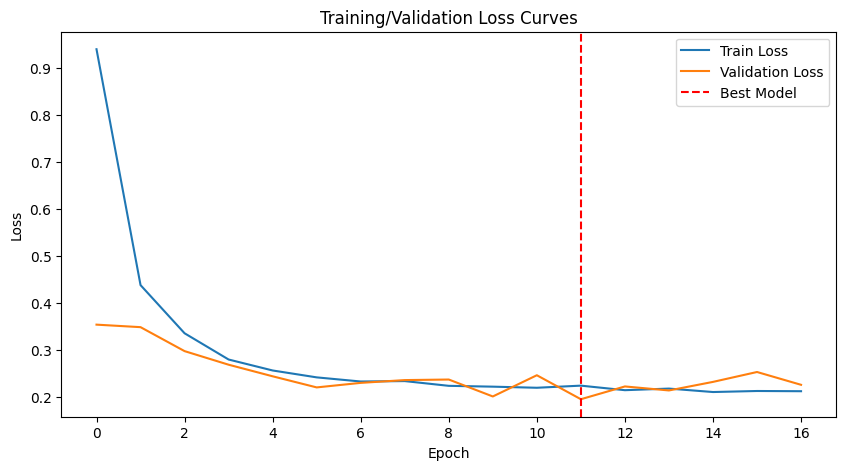

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import numpy as np
from sklearn.metrics import mean_squared_error
import random
import matplotlib.pyplot as plt

# Fix seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Enhanced Loss Function
class StockLoss(nn.Module):
    def __init__(self, delta=0.5, direction_weight=0.6, margin=0.02):
        super().__init__()
        self.huber = nn.HuberLoss(delta=delta)
        self.direction_weight = direction_weight
        self.margin = margin
        
    def forward(self, preds, targets):
        # Base regression loss
        huber_loss = self.huber(preds, targets)
        
        # Directional loss only for multi-step predictions
        if preds.size(1) > 1:
            pred_dirs = preds[:, 1:] - preds[:, :-1]
            true_dirs = targets[:, 1:] - targets[:, :-1]
            
            # Only consider significant movements
            significant_moves = (true_dirs.abs() > self.margin).float()
            dir_accuracy = torch.sign(pred_dirs * true_dirs)
            
            # Loss for wrong directions on significant moves
            dir_loss = torch.mean(torch.relu(-dir_accuracy * significant_moves))
        else:
            dir_loss = torch.tensor(0.0, device=preds.device)
            
        return huber_loss + self.direction_weight * dir_loss

# Initialize your existing encoder (unchanged)
encoder = StockMambaEncoder(input_features=7, d_model=64)
decoder = StockMambaDecoder(input_dim=7, output_dim=1, pred_length=5)
model = nn.ModuleDict({'encoder': encoder, 'decoder': decoder}).to(device)

# Stronger regularization in optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)  # Increased weight decay
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)
criterion = StockLoss(delta=0.5, direction_weight=0.6, margin=0.02).to(device)

def train(model, train_loader, val_loader, epochs):
    best_val_loss = float('inf')
    no_improve = 0
    patience = 5
    train_losses = []
    val_losses = []
    
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_train_losses = []
        
        # Data augmentation with Gaussian noise
        for batch_X, batch_y in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            if model.training:  # Only add noise during training
                batch_X = batch_X + torch.randn_like(batch_X) * 0.01  # 1% noise
            
            optimizer.zero_grad()
            
            # Forward pass
            enc_out = model['encoder'](batch_X)
            preds, _ = model['decoder'](batch_X[:, -1:, :], enc_out)
            loss = criterion(preds.squeeze(1), batch_y.squeeze(-1))
            
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)  # Tighter clipping
            optimizer.step()
            
            epoch_train_losses.append(loss.item())
        
        # Validation
        val_loss, val_rmse = evaluate(model, val_loader)
        scheduler.step(val_loss)
        
        # Track losses
        avg_train_loss = np.mean(epoch_train_losses)
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch}: Train Loss={avg_train_loss:.4f}, Val Loss={val_loss:.4f}, Val RMSE={val_rmse:.4f}")
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve = 0
            torch.save(model.state_dict(), "best_mamba_stock.pth")
            print("-> Saved Best Model")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch}")
                break
    
    # Plot learning curves
    plt.figure(figsize=(10,5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.axvline(np.argmin(val_losses), color='r', linestyle='--', label='Best Model')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training/Validation Loss Curves')
    plt.show()

def evaluate(model, val_loader):
    model.eval()
    losses = []
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            enc_out = model['encoder'](batch_X)
            preds, _ = model['decoder'](batch_X[:, -1:, :], enc_out)
            
            loss = criterion(preds.squeeze(1), batch_y.squeeze(-1))
            losses.append(loss.item())
            
            all_preds.append(preds.squeeze(1).cpu().numpy())
            all_targets.append(batch_y.squeeze(-1).cpu().numpy())
    
    avg_loss = np.mean(losses)
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    
    return avg_loss, rmse

# Start training
train(model, train_loader, val_loader, epochs=50)

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model, test_loader, device):
    model.eval()
    total_loss = 0
    criterion = nn.MSELoss()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in test_loader:
            src, target = batch
            src, target = src.to(device), target.to(device)

            enc_output = model['encoder'](src)
            dec_input = src[:, -1:, :]  # last timestep input
            preds, _ = model['decoder'](dec_input, enc_output)

            loss = criterion(preds.squeeze(1), target)
            total_loss += loss.item()

            all_preds.append(preds.squeeze(1).cpu().numpy())  # fix here
            all_targets.append(target.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    mae = mean_absolute_error(all_targets, all_preds)
    r2 = r2_score(all_targets, all_preds)

    print(f"\n📉 Evaluation Metrics:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2 Score: {r2:.4f}")

    return total_loss / len(test_loader)

# Ensure model is on the same device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = nn.ModuleDict({'encoder': encoder, 'decoder': decoder}).to(device)

# Evaluate
val_loss = evaluate_model(model, test_loader, device)
print(f"\n🔎 Average Validation MSE Loss: {val_loss:.6f}")



📉 Evaluation Metrics:
RMSE: 0.2629
MAE: 0.1894
R2 Score: 0.7483

🔎 Average Validation MSE Loss: 0.066516
